# Lab Assessment: Understanding and Classifying Data for Customer Analytics

Assume you are data analyst in RetailMart.Sdn.Bhd, and are responsible for helping the company analyze customer data. The company has collected various types of data about customers and their purchasing behavior. Before depth into advanced analytics, you are tasked with understanding and classifying the collected data into appropriate types (Nominal, Ordinal, Interval, or Ratio). In addition, you are required to review the data to identify issues such as duplicates, missing values, and inconsistent formats. If you notice any issues, you are required to perform the cleaning process and ensure its quality

Dataset Description:
- The dataset contains the following columns:
1. CustomerID: A unique ID assigned to each customer.
2. Name: The name of the customer.
3. Gender: The gender of the customer (Male, Female).
4. Age: The age of the customer in years.
5. Income: The monthly income of the customer in MYR.
6. Membership_Level: The membership tier of the customer (Bronze, Silver, Gold, Platinum).
7. Last_Purchase_Amount: The amount spent by the customer in their most recent purchase (MYR).
8. Customer_Satisfaction_Score: A score provided by customers after their last purchase (1 = Very Dissatisfied, 5 = Very Satisfied).


## **Task 1: Load and Explore the Dataset**

In [72]:
# Import all libraries will be used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# Load the dataset
df = pd.read_csv('RetailMartCustomers.csv')

In [58]:
# Display the first 10 rows and last 5 rows
print("First 10 rows: ")
print(df.head(10))

First 10 rows: 
   CustomerID           Name  Gender   Age  Income (MYR) Membership_Level  \
0           1   Lim Mei Ling    Male  30.0       11678.0             Gold   
1           2   Siti Fatimah    Male  61.0        7345.0         Platinum   
2           3    Siti Aisyah  Female  60.0       13357.0           Bronze   
3           4   Anita Kumari    Male  24.0       10202.0           Bronze   
4           5     Anita Devi  Female  63.0       11525.0             Gold   
5           6     Lim Li Hua    Male  41.0       13606.0         Platinum   
6           7    Siti Aminah  Female  22.0        9143.0             Gold   
7           8    Lim Hui Min    Male  60.0       14912.0         Platinum   
8           9     Anita Devi    Male  52.0       12383.0           Bronze   
9          10  Siti Zulaikha    Male  50.0        3853.0             Gold   

   Last_Purchase_Amount (MYR)  Customer_Satisfaction_Score  
0                      809.74                            4  
1             

In [56]:
print("Last 5 rows: ")
print(df.tail(5))

Last 5 rows: 
     CustomerID           Name  Gender   Age  Income (MYR) Membership_Level  \
730         134    Siti Aminah  Female  46.0        2633.0         Platinum   
731         534  Anita Lakshmi  Female  51.0        3572.0           Bronze   
732         137   Lim Mei Ling  Female  42.0           NaN           Bronze   
733         110   Lim Mei Ling    Male  46.0       11648.0           Bronze   
734         182  Anita Lakshmi  Female  66.0       12573.0           Silver   

     Last_Purchase_Amount (MYR)  Customer_Satisfaction_Score  
730                       71.20                            5  
731                      924.42                            1  
732                      377.30                            5  
733                      177.03                            1  
734                      256.04                            2  


In [64]:
# Summary of Dataframe
print("Summary of Dataframe: ")
df.info()

Summary of Dataframe: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   735 non-null    int64  
 1   Name                         735 non-null    object 
 2   Gender                       735 non-null    object 
 3   Age                          698 non-null    float64
 4   Income (MYR)                 664 non-null    float64
 5   Membership_Level             735 non-null    object 
 6   Last_Purchase_Amount (MYR)   658 non-null    float64
 7   Customer_Satisfaction_Score  735 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 46.1+ KB


##### Objective 1: Identify and classify the types of data (nominal, ordinal, interval, ratio).

In [90]:
# Define the dataset structure
columns = [
    {"Column": "CustomerID", "Non-Null Count": 735, "Dtype": "int64"},
    {"Column": "Name", "Non-Null Count": 735, "Dtype": "object"},
    {"Column": "Gender", "Non-Null Count": 735, "Dtype": "object"},
    {"Column": "Age", "Non-Null Count": 698, "Dtype": "float64"},
    {"Column": "Income (MYR)", "Non-Null Count": 664, "Dtype": "float64"},
    {"Column": "Membership_Level", "Non-Null Count": 735, "Dtype": "object"},
    {"Column": "Last_Purchase_Amount (MYR)", "Non-Null Count": 658, "Dtype": "float64"},
    {"Column": "Customer_Satisfaction_Score", "Non-Null Count": 735, "Dtype": "int64"},
]

# Define the classification for each column
classifications = {
    "CustomerID": {"Data Type": "Nominal", "Justification": "Unique identifier for each customer with no intrinsic order or numerical significance."},
    "Name": {"Data Type": "Nominal", "Justification": "Represents names of customers. Names are labels with no numeric or ranked meaning."},
    "Gender": {"Data Type": "Nominal", "Justification": "Represents categories ('Male', 'Female') with no intrinsic order or numeric value."},
    "Age": {"Data Type": "Ratio", "Justification": "Represents the age of customers, a continuous variable with a true zero point (e.g., 0 years)."},
    "Income (MYR)": {"Data Type": "Ratio", "Justification": "Monthly income is a continuous variable with a true zero, where 0 means no income."},
    "Membership_Level": {"Data Type": "Ordinal", "Justification": "Represents ranked categories ('Bronze', 'Silver', 'Gold', 'Platinum') with an inherent order."},
    "Last_Purchase_Amount (MYR)": {"Data Type": "Ratio", "Justification": "Represents a monetary value (continuous) with a true zero, where 0 means no purchase."},
    "Customer_Satisfaction_Score": {"Data Type": "Ordinal", "Justification": "Represents satisfaction scores on a scale (1 to 5), which indicates ranking but not equal intervals."},
}

# Populate a list with classification and justification
classification_data = [
    {
        "Column": col["Column"],
        "Data Type": classifications[col["Column"]]["Data Type"],
        "Justification": classifications[col["Column"]]["Justification"],
    }
    for col in columns
]

# Convert the list to a DataFrame
classification_df = pd.DataFrame(classification_data)

# Display the table
from IPython.display import display

print("Classification of Dataset Columns: ")
display(classification_df.style.set_properties(**{'text-align': 'justify'}))

Classification of Dataset Columns: 


,Column,Data Type,Justification
0,CustomerID,Nominal,Unique identifier for each customer with no intrinsic order or numerical significance.
1,Name,Nominal,Represents names of customers. Names are labels with no numeric or ranked meaning.
2,Gender,Nominal,"Represents categories ('Male', 'Female') with no intrinsic order or numeric value."
3,Age,Ratio,"Represents the age of customers, a continuous variable with a true zero point (e.g., 0 years)."
4,Income (MYR),Ratio,"Monthly income is a continuous variable with a true zero, where 0 means no income."
5,Membership_Level,Ordinal,"Represents ranked categories ('Bronze', 'Silver', 'Gold', 'Platinum') with an inherent order."
6,Last_Purchase_Amount (MYR),Ratio,"Represents a monetary value (continuous) with a true zero, where 0 means no purchase."
7,Customer_Satisfaction_Score,Ordinal,"Represents satisfaction scores on a scale (1 to 5), which indicates ranking but not equal intervals."


Summary of Data Types
1. Nominal:
    - Used for categorical data with no order or ranking.
    - Columns: CustomerID, Name, Gender.
2. Ordinal:
    - Used for categorical data with a meaningful order but unequal intervals.
    - Columns: Membership_Level, Customer_Satisfaction_Score.
3. Ratio:
    - Used for continuous numerical data with a true zero.
    - Columns: Age, Income (MYR), Last_Purchase_Amount (MYR).

## **Task 2: Analyze the Data**

In [88]:
# Total records
total_records = df.shape[0]
print(f"Total records in the dataset: {total_records}")

Total records in the dataset: 735


In [104]:
# Summary statistics for numerical columns
print("\nSummary Statistics: ")
df.describe()


Summary Statistics: 


,CustomerID,Age,Income (MYR),Last_Purchase_Amount (MYR),Customer_Satisfaction_Score
count,735.000000,698.000000,664.000000,658.000000,735.000000
mean,349.778231,44.416905,8591.350904,522.321231,3.017687
std,200.684146,15.325717,3880.349441,274.941888,1.417471
min,1.000000,18.000000,2012.000000,51.000000,1.000000
25%,177.500000,31.000000,5100.500000,291.340000,2.000000
50%,347.000000,45.000000,8711.500000,513.790000,3.000000
75%,522.500000,58.000000,12065.250000,763.832500,4.000000
max,700.000000,70.000000,15000.000000,996.620000,5.000000


In [110]:
# Set global float format for pandas
pd.options.display.float_format = '{:.2f}'.format

# Display summary statistics
print("\nSummary Statistics: ")
df.describe()


Summary Statistics: 


,CustomerID,Age,Income (MYR),Last_Purchase_Amount (MYR),Customer_Satisfaction_Score
count,735.00,698.00,664.00,658.00,735.00
mean,349.78,44.42,8591.35,522.32,3.02
std,200.68,15.33,3880.35,274.94,1.42
min,1.00,18.00,2012.00,51.00,1.00
25%,177.50,31.00,5100.50,291.34,2.00
50%,347.00,45.00,8711.50,513.79,3.00
75%,522.50,58.00,12065.25,763.83,4.00
max,700.00,70.00,15000.00,996.62,5.00


Check and Count Gender Category

In [118]:
# Count the occurrences of each gender
gender_counts = df['Gender'].value_counts()

# Convert to a DataFrame for better table representation
gender_table = gender_counts.reset_index()
gender_table.columns = ['Gender', 'Total']

# Display the table
print("Gender Categories and Total Counts")
print(gender_table)

Gender Categories and Total Counts
   Gender  Total
0    Male    368
1  Female    367


In [120]:
# Identify missing values
missing_values = df.isnull().sum()
print("\nMissing Values: ")
print(missing_values)


Missing Values: 
CustomerID                      0
Name                            0
Gender                          0
Age                            37
Income (MYR)                   71
Membership_Level                0
Last_Purchase_Amount (MYR)     77
Customer_Satisfaction_Score     0
dtype: int64



# Justifications for Handling Missing Values

### 1. Age
- **Nature of Data**:
  - Numerical, continuous, and represents the age of the customer.
  - Missing values may occur due to incomplete data collection.
- **Suggested Solution**:
  - Replace missing values with the median of the `Age` column.
- **Justification**:
  - The median is robust to outliers, which ensures the missing values are filled with a central value that is not overly influenced by extreme ages.


### 2. Income (MYR)
- **Nature of Data**:
  - Numerical, continuous, and represents the monthly income of the customer.
  - Missing values may be due to customers not disclosing their income.
- **Suggested Solution**:
  - Replace missing values with the mean of the `Income (MYR)` column.
- **Justification**:
  - The mean provides a good central tendency for income and preserves the overall distribution of the dataset.


### 3. Last_Purchase_Amount (MYR)
- **Nature of Data**:
  - Numerical, continuous, and represents the amount spent in the customer's last purchase.
  - Missing values might indicate no purchase was made.
- **Suggested Solution**:
  - Replace missing values with `0`.
- **Justification**:
  - Replacing with 0 reflects the reality of no purchase made and avoids misrepresentation by imputing an average or median value, which would suggest a purchase was made.


##### Summary Table of Handling Missing Values

| **Column**                 | **Solution**         | **Justification**                                                                 |
|----------------------------|----------------------|-----------------------------------------------------------------------------------|
| **Age**                    | Replace with median  | Robust to outliers and represents central tendency of age data.                  |
| **Income (MYR)**           | Replace with mean    | Preserves overall distribution and represents typical income.                    |
| **Last_Purchase_Amount (MYR)** | Replace with 0     | Reflects no purchase made; avoids misrepresenting non-purchasers.                |


## **Task 3: Identify and Handle Duplicates**

In [156]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate record (rows): {duplicates}")


Number of duplicate record (rows): 35


In [214]:
# Remove duplicates and retain the first occurrence, drop()
df = df.drop_duplicates()
print(f"Dataset after removing duplicates: {df.shape[0]}rows")

Dataset after removing duplicates: 700rows


In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   700 non-null    int64  
 1   Name                         700 non-null    object 
 2   Gender                       700 non-null    object 
 3   Age                          663 non-null    float64
 4   Income (MYR)                 634 non-null    float64
 5   Membership_Level             700 non-null    object 
 6   Last_Purchase_Amount (MYR)   629 non-null    float64
 7   Customer_Satisfaction_Score  700 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 49.2+ KB


In [220]:
# verify the duplicates data
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate record (rows): {duplicates}")


Number of duplicate record (rows): 0


## **Task 4: Handle Missing Values**

In [188]:
# Display initial missing values
print("Missing Values (Before Handling): ")
print(customer.isnull().sum())

Missing Values (Before Handling): 
CustomerID                     0
Name                           0
Gender                         0
Age                            0
Income (MYR)                   0
Membership_Level               0
Last_Purchase_Amount (MYR)     0
Customer_Satisfaction_Score    0
dtype: int64


In [190]:
# 1. Handle missing values in the 'Age' column
customer['Age'].fillna(customer['Age'].median(), inplace=True)

# 2. Handle missing values in the 'Income (MYR)' column
customer['Income (MYR)'].fillna(customer['Income (MYR)'].mean(), inplace=True)

# 3. Handle missing values in the 'Last_Purchase_Amount (MYR)' column
customer['Last_Purchase_Amount (MYR)'].fillna(0, inplace=True)

# Display missing values after handling
print("\nMissing Values (After handling): ")
print(customer.isnull().sum())


Missing Values (After handling): 
CustomerID                     0
Name                           0
Gender                         0
Age                            0
Income (MYR)                   0
Membership_Level               0
Last_Purchase_Amount (MYR)     0
Customer_Satisfaction_Score    0
dtype: int64


C:\Users\SleepyAsh\AppData\Local\Temp\ipykernel_9764\4223207446.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer['Age'].fillna(customer['Age'].median(), inplace=True)
C:\Users\SleepyAsh\AppData\Local\Temp\ipykernel_9764\4223207446.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer['Age'].fillna(customer['Age'].median(), i

In [192]:
# View the record
df.head()

,CustomerID,Name,Gender,Age,Income (MYR),Membership_Level,Last_Purchase_Amount (MYR),Customer_Satisfaction_Score
0,1,Lim Mei Ling,Male,30.00,11678.00,Gold,809.74,4
1,2,Siti Fatimah,Male,61.00,7345.00,Platinum,852.06,1
2,3,Siti Aisyah,Female,60.00,13357.00,Bronze,500.42,3
3,4,Anita Kumari,Male,24.00,10202.00,Bronze,51.00,3
4,5,Anita Devi,Female,63.00,11525.00,Gold,759.34,2


In [4]:
# Replace missing values


# Verify missing values are handled




Missing values after handling:
CustomerID                     0
Name                           0
Gender                         0
Age                            0
Income (MYR)                   0
Membership_Level               0
Last_Purchase_Amount (MYR)     0
Customer_Satisfaction_Score    0
dtype: int64


## **Task 5: Fix Inconsistent Data**

In [194]:
# Standardize Gender column
customer['Gender'] = customer['Gender'].str.capitalize()
 
# Ensure consistent capitalization in Membership_Level
customer['Membership_Level'] = customer['Membership_Level'].str.capitalize()

# Verify corrections
print("\nUnique values in Gender: ")
print(customer['Gender'].unique())

print("\nUnique values in Membership Level: ")
print(customer['Membership_Level'].unique())


Unique values in Gender: 
['Male' 'Female']

Unique values in Membership Level: 
['Gold' 'Platinum' 'Bronze' 'Silver']


C:\Users\SleepyAsh\AppData\Local\Temp\ipykernel_9764\4188653440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer['Gender'] = customer['Gender'].str.capitalize()
C:\Users\SleepyAsh\AppData\Local\Temp\ipykernel_9764\4188653440.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer['Membership_Level'] = customer['Membership_Level'].str.capitalize()


## **Task 6: Perform Data Analysis**

         Age  Income (MYR)  Last_Purchase_Amount (MYR)
count 700.00        700.00                      700.00
mean   44.30       8571.41                      468.11
std    14.95       3693.39                      304.89
min    18.00       2012.00                        0.00
25%    32.00       5415.00                      193.16
50%    45.00       8571.41                      470.61
75%    57.00      11726.00                      748.27
max    70.00      15000.00                      996.62


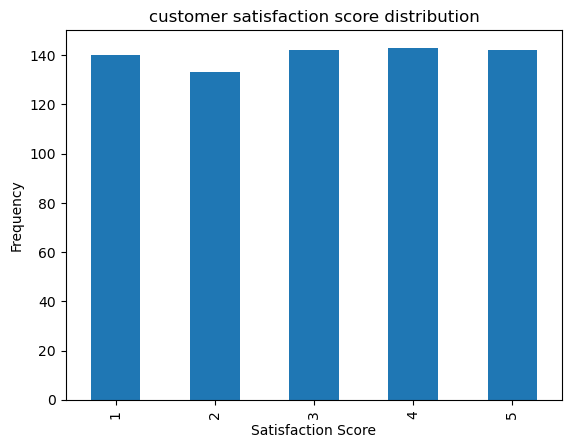

In [200]:
# Descriptive statistics for numerical columns
print(customer[['Age', 'Income (MYR)', 'Last_Purchase_Amount (MYR)']].describe())

# Visualize customer satisfaction score distribution
customer['Customer_Satisfaction_Score'].value_counts().sort_index().plot(kind='bar', title='customer satisfaction score distribution')
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')

plt.show()

In [37]:
# Analyze average income and satisfaction scores for each membership level



Average Income and Satisfaction Scores by Membership Level:
                  Income (MYR)  Customer_Satisfaction_Score
Membership_Level                                           
Bronze                 8985.85                         2.98
Gold                   7930.34                         2.87
Platinum               8586.36                         3.03
Silver                 8762.05                         3.19


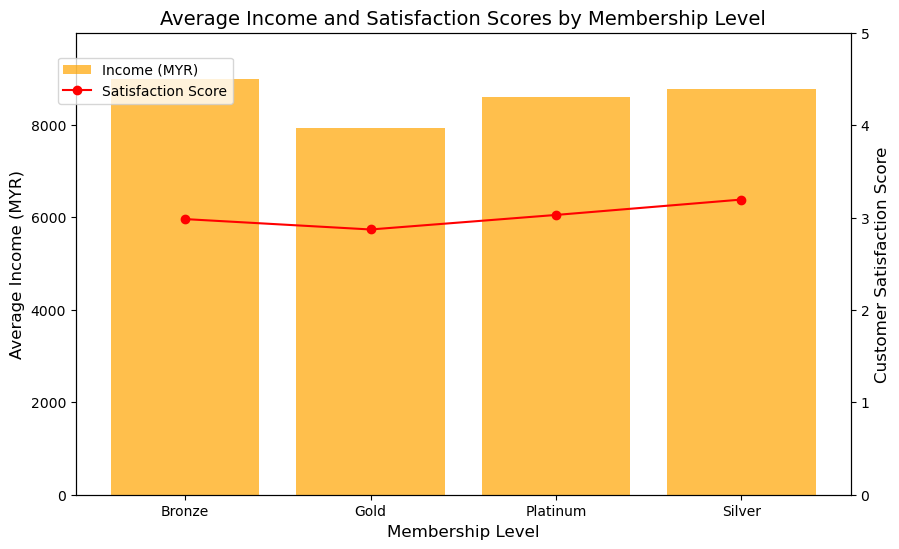

In [38]:
# Reset index to use 'Membership_Level' for plotting
membership_analysis = membership_analysis.reset_index()

# Plotting the chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot bar chart for Average Income
bar = ax1.bar(membership_analysis['Membership_Level'], 
              membership_analysis['Income (MYR)'], 
              color='orange', alpha=0.7, label='Income (MYR)')
ax1.set_ylabel('Average Income (MYR)', fontsize=12)
ax1.set_xlabel('Membership Level', fontsize=12)
ax1.set_ylim(0, membership_analysis['Income (MYR)'].max() + 1000)
ax1.tick_params(axis='y')

# Add a secondary y-axis for Satisfaction Score
ax2 = ax1.twinx()
line = ax2.plot(membership_analysis['Membership_Level'], 
                membership_analysis['Customer_Satisfaction_Score'], 
                marker='o', color='red', label='Satisfaction Score')
ax2.set_ylabel('Customer Satisfaction Score', fontsize=12)
ax2.set_ylim(0, 5)

# Add title and legends
plt.title('Average Income and Satisfaction Scores by Membership Level', fontsize=14)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85))

# Display the chart
plt.show()


## **Task 7: Save Cleaned Data**

In [222]:
# Save the cleaned dataset
df.to_csv('retail_cleaned.csv', index=False)
print("Cleaned dataset")

Cleaned dataset


### Justification and Opinion Based on Results

##### 1. Bronze Membership
- **Observation**: 
  - Highest average income (~8985 MYR).
  - Moderate satisfaction score (~2.98).
- **Justification**: 
  - Bronze members might represent a broad customer base with diverse spending capacities. High income could mean this tier attracts individuals who are willing to spend but expect value in return.
  - Slightly lower satisfaction suggests that this group may not feel sufficiently rewarded or acknowledged compared to higher-tier members.
- **Opinion**: 
  - RetailMart should consider introducing enhanced benefits or rewards specifically tailored to Bronze members. This could include personalized discounts, loyalty points, or exclusive offers to improve their satisfaction.



##### 2. Gold Membership
- **Observation**:
  - Lowest average income (~7930 MYR).
  - Lowest satisfaction score (~2.87).
- **Justification**:
  - Gold members might feel that the benefits of this tier do not justify the costs or expectations associated with being part of a premium tier. This discrepancy could lead to dissatisfaction and a perception that the tier lacks value.
- **Opinion**:
  - RetailMart should urgently review the Gold membership structure. Possible actions include:
    - Introducing additional perks such as free shipping, priority customer support, or larger discounts.
    - Conducting surveys to understand specific dissatisfaction points among Gold members.
  - This tier requires targeted marketing and enhancements to both attract and retain members.



##### 3. Platinum Membership
- **Observation**:
  - Moderate average income (~8586 MYR).
  - Moderate satisfaction score (~3.03).
- **Justification**:
  - Platinum members might be relatively satisfied with their benefits, but there’s no standout indicator of exceptional performance for this tier.
- **Opinion**:
  - Platinum members expect exclusivity and high-value offerings. To improve satisfaction and loyalty, RetailMart could:
    - Introduce elite benefits, such as early access to sales or personalized shopping experiences.
    - Focus on relationship management to make Platinum members feel valued.


##### 4. Silver Membership
- **Observation**:
  - Second-highest average income (~8762 MYR).
  - Highest satisfaction score (~3.19).
- **Justification**:
  - Silver members likely see their benefits as aligned with their expectations and spending behavior, leading to the highest satisfaction score.
- **Opinion**:
  - RetailMart should maintain the current offerings for Silver members. However, the company could also explore upselling strategies to transition satisfied Silver members into higher tiers (e.g., Platinum) by highlighting additional exclusive benefits.



### Overall Recommendations
1. **Focus on Gold Membership**:
   - Address dissatisfaction and enhance benefits to justify the tier’s premium status.
   - Conduct customer feedback surveys to identify specific pain points.

2. **Retain Silver Membership Strengths**:
   - Leverage Silver as a benchmark for balancing cost and perceived value.
   - Upsell to other tiers while maintaining high satisfaction levels.

3. **Reward High-Income Bronze Members**:
   - Tailor loyalty programs for Bronze members to improve satisfaction and encourage upgrades to higher tiers.

4. **Increase Platinum Exclusivity**:
   - Make Platinum more aspirational by introducing unique perks and exclusivity.



### Strategic Insights
- The data reveals gaps in value perception for certain membership levels, particularly Gold.
- High-income Bronze members represent an untapped opportunity for upselling.
- Silver membership provides a strong foundation for balancing cost, income, and satisfaction but should be complemented by strategies to increase member spending and upgrades.

These justifications and opinions provide actionable insights for RetailMart to improve customer experience, satisfaction, and loyalty while potentially increasing revenue across all membership levels.


## **Task 8: Summary Report**

In [40]:

summary = """
Data Quality Issues Found:
1. Missing values in Age, Income (MYR), and Last_Purchase_Amount (MYR) columns.
2. Duplicates found and removed.
3. Inconsistent formats in Gender and Membership_Level columns.

Resolutions:
1. Replaced missing Age with median, Income with mean, and Last_Purchase_Amount with 0.
2. Removed duplicates retaining the first occurrence.
3. Standardized Gender and Membership_Level values.

Insights:
1. Customer satisfaction scores are evenly distributed with slight peaks in scores 4 and 5.
2. Average income and satisfaction scores vary across membership levels, suggesting tier-specific marketing strategies.
"""

print(summary)



Data Quality Issues Found:
1. Missing values in Age, Income (MYR), and Last_Purchase_Amount (MYR) columns.
2. Duplicates found and removed.
3. Inconsistent formats in Gender and Membership_Level columns.

Resolutions:
1. Replaced missing Age with median, Income with mean, and Last_Purchase_Amount with 0.
2. Removed duplicates retaining the first occurrence.
3. Standardized Gender and Membership_Level values.

Insights:
1. Customer satisfaction scores are evenly distributed with slight peaks in scores 4 and 5.
2. Average income and satisfaction scores vary across membership levels, suggesting tier-specific marketing strategies.



# PART B (Analysis Question)

Perform the analysis and critique the result.
1. What is the distribution of genders (Male and Female) in the dataset? Visualize the results and interpret the findings.
2. What is the distribution of customers across membership levels? Which level has the highest representation, and what could this imply for RetailMart?
3. Is there a relationship between customer income and satisfaction scores? Use statistical methods and visualizations to explore this relationship.
4. What is the average Last_Purchase_Amount (MYR) for each membership level? Visualize the results and discuss possible reasons for any differences.
5. What is the age distribution of customers? Are there noticeable trends or clusters in certain age ranges?
6. Summarize three key insights from your analysis that RetailMart could use to improve customer satisfaction and increase revenue.
